<a href="https://colab.research.google.com/github/sdavanipur/Continuous-Thought-Machines/blob/main/Object_Detection_CTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Continuous Thought Machines (CTMs) on Object Detection

In this notebook, I sought to implement and train a recently proposed architecture of Deep Neural Networks whose functioning resembles that of their biological counterparts in terms of time, that is to say, their information processing takes place across a number of internal ticks where the neurons' states are updated iteratively, hence, the time coordinate has been added to their functioning in order to make their behavior richer.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
import matplotlib.patches as patches

import torch.optim as optim



In [ ]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


--- Starting CTM Convergence Test (80 Epochs) ---
Epoch [01/80] | Convergence Loss: 5.3988
Epoch [10/80] | Convergence Loss: 3.7987
Epoch [20/80] | Convergence Loss: 3.2312
Epoch [30/80] | Convergence Loss: 3.0596
Epoch [40/80] | Convergence Loss: 2.7441
Epoch [50/80] | Convergence Loss: 2.5250
Epoch [60/80] | Convergence Loss: 2.1332
Epoch [70/80] | Convergence Loss: 2.0995
Epoch [80/80] | Convergence Loss: 2.2318


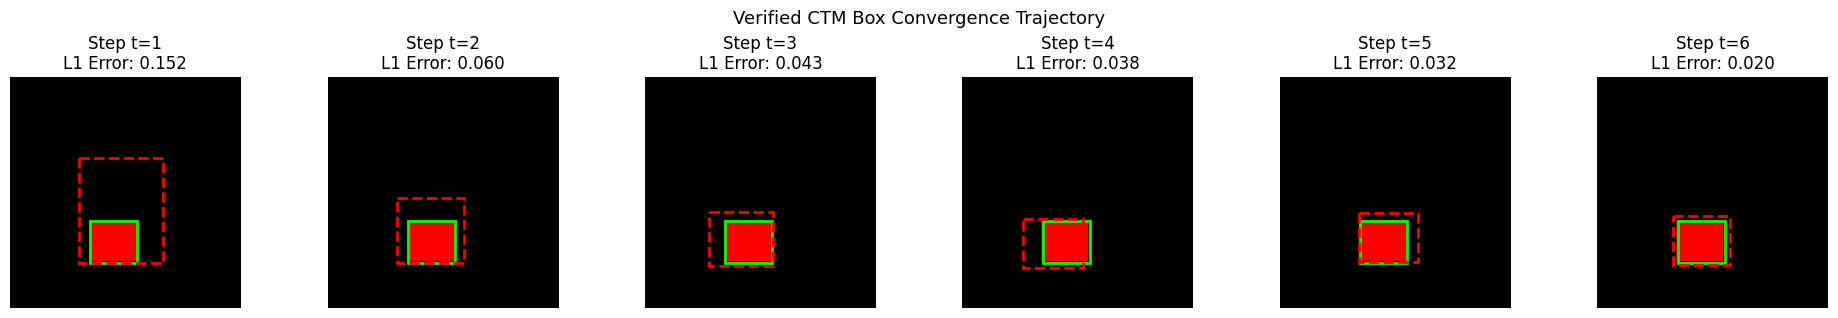

In [ ]:


# =====================================================================
# 1. Box Utilities: Box Conversion & Generalized IoU (GIoU) Loss
# =====================================================================
def box_cxcywh_to_xyxy(x: torch.Tensor) -> torch.Tensor:
    """Converts [center_x, center_y, w, h] to [x1, y1, x2, y2]."""
    x_c, y_c, w, h = x.unbind(-1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h), (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=-1)


def giou_loss(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """
    Computes GIoU Loss between predictions and targets in [cx, cy, w, h] format.
    preds: (B, 4), targets: (B, 4)
    """
    b1 = box_cxcywh_to_xyxy(preds)
    b2 = box_cxcywh_to_xyxy(targets)

    # Intersection coordinates
    lt = torch.max(b1[:, :2], b2[:, :2])
    rb = torch.min(b1[:, 2:], b2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, 0] * wh[:, 1]

    # Areas
    area1 = (b1[:, 2] - b1[:, 0]) * (b1[:, 3] - b1[:, 1])
    area2 = (b2[:, 2] - b2[:, 0]) * (b2[:, 3] - b2[:, 1])
    union = area1 + area2 - inter

    iou = inter / (union + 1e-6)

    # Enclosing box coordinates
    lt_c = torch.min(b1[:, :2], b2[:, :2])
    rb_c = torch.max(b1[:, 2:], b2[:, 2:])
    wh_c = (rb_c - lt_c).clamp(min=0)
    enclosing_area = wh_c[:, 0] * wh_c[:, 1]

    giou = iou - (enclosing_area - union) / (enclosing_area + 1e-6)
    return (1.0 - giou).mean()


# =====================================================================
# 2. Single-Object Dataset
# =====================================================================
class SingleObjectDataset(Dataset):
    """Generates synthetic images containing exactly ONE red square object."""
    def __init__(self, num_samples: int = 64, img_size: int = 128):
        super().__init__()
        self.num_samples = num_samples
        self.img_size = img_size

        # Pre-generate deterministic samples for robust overfitting test
        torch.manual_seed(42)
        self.data = []
        for _ in range(num_samples):
            img = torch.zeros(3, img_size, img_size, dtype=torch.float32)
            w_px, h_px = torch.randint(20, 36, (2,)).tolist()
            x_c_px = torch.randint(w_px // 2 + 10, img_size - w_px // 2 - 10, (1,)).item()
            y_c_px = torch.randint(h_px // 2 + 10, img_size - h_px // 2 - 10, (1,)).item()

            y1, y2 = max(0, y_c_px - h_px // 2), min(img_size, y_c_px + h_px // 2)
            x1, x2 = max(0, x_c_px - w_px // 2), min(img_size, x_c_px + w_px // 2)
            img[0, y1:y2, x1:x2] = 1.0  # Bright Red Square

            box = torch.tensor([
                x_c_px / img_size,
                y_c_px / img_size,
                w_px / img_size,
                h_px / img_size
            ], dtype=torch.float32)
            self.data.append((img, box))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.data[idx]


# =====================================================================
# 3. CTM Architecture with Trajectory Tracking
# =====================================================================
class CTMObjectDetector(nn.Module):
    def __init__(self, img_size: int = 128, num_queries: int = 8, hidden_dim: int = 128, max_steps: int = 6): # Added img_size, renamed embed_dim to hidden_dim
        super().__init__()
        self.img_size = img_size # Store img_size
        self.num_queries = num_queries
        self.max_steps = max_steps

        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # (B, 32, H/2, W/2)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, hidden_dim, kernel_size=3, stride=2, padding=1),  # (B, hidden_dim, H/4, W/4)
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU()
        )

        self.query_embed = nn.Parameter(torch.randn(1, num_queries, hidden_dim) * 0.02) # Use hidden_dim here

        self.cross_attn = nn.MultiheadAttention(hidden_dim, num_heads=4, batch_first=True) # Use hidden_dim here
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2), # Use hidden_dim here
            nn.GELU(),
            nn.Linear(hidden_dim * 2, hidden_dim)  # Use hidden_dim here
        )
        self.norm1 = nn.LayerNorm(hidden_dim) # Use hidden_dim here
        self.norm2 = nn.LayerNorm(hidden_dim) # Use hidden_dim here

        self.bbox_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), # Use hidden_dim here
            nn.ReLU(),
            nn.Linear(hidden_dim, 4), # Use hidden_dim here
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor):
        B = x.shape[0]
        feat = self.backbone(x)
        h_spatial = feat.flatten(2).permute(0, 2, 1)

        z_t = self.query_embed.repeat(B, 1, 1)
        trajectory_boxes = []

        for _ in range(self.max_steps):
            attn_out, _ = self.cross_attn(z_t, h_spatial, h_spatial)
            z_t = self.norm1(z_t + attn_out)
            z_t = self.norm2(z_t + self.ffn(z_t))

            pred_boxes = self.bbox_head(z_t)  # (B, num_queries, 4)
            trajectory_boxes.append(pred_boxes)

        # Returns full evolution across step sequence: (max_steps, B, num_queries, 4)
        return torch.stack(trajectory_boxes, dim=0)


# =====================================================================
# 4. Training Loop with Minimum-Distance Assignment
# =====================================================================
def train_and_verify():
    dataset = SingleObjectDataset(num_samples=32, img_size=128)
    dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

    model = CTMObjectDetector(num_queries=8, hidden_dim=128, max_steps=6).to(device) # Updated here too
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

    num_epochs = 80
    print(f"--- Starting CTM Convergence Test ({num_epochs} Epochs) ---")

    model.train()
    for epoch in range(num_epochs):
        total_loss = 0.0

        for images, target_boxes in dataloader:
            images = images.to(device)
            target_boxes = target_boxes.to(device)  # (B, 4)

            optimizer.zero_grad()

            # Forward pass: (max_steps, B, num_queries, 4)
            traj_boxes = model(images)
            final_boxes = traj_boxes[-1]  # Evaluate final convergence step (B, num_queries, 4)

            # Minimum-Distance Matching: Find query with lowest L1 distance to target per image
            target_expanded = target_boxes.unsqueeze(1).repeat(1, model.num_queries, 1)  # (B, N_q, 4)
            l1_per_query = torch.abs(final_boxes - target_expanded).sum(dim=-1)  # (B, N_q)

            min_indices = l1_per_query.argmin(dim=1)  # Best matching query index per image
            matched_pred_boxes = final_boxes[torch.arange(images.shape[0]), min_indices]  # (B, 4)

            # Combined Loss: L1 + GIoU on matched best query
            loss_l1 = F.l1_loss(matched_pred_boxes, target_boxes)
            loss_giou = giou_loss(matched_pred_boxes, target_boxes)

            loss = 2.0 * loss_l1 + 5.0 * loss_giou

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:02d}/{num_epochs}] | Convergence Loss: {avg_loss:.4f}")

    return model, dataset


# =====================================================================
# 5. Trajectory Visualization
# =====================================================================
def visualize_step_by_step(model, dataset, sample_idx=0):
    model.eval()
    img_tensor, target_box = dataset[sample_idx]

    with torch.no_grad():
        x = img_tensor.unsqueeze(0).to(device)
        traj_boxes = model(x)  # (max_steps, 1, num_queries, 4)

    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_h, img_w, _ = img_np.shape
    num_steps = traj_boxes.shape[0]

    fig, axes = plt.subplots(1, num_steps, figsize=(3.2 * num_steps, 3.2))
    gt_cx, gt_cy, gt_w, gt_h = target_box.numpy()

    for t in range(num_steps):
        ax = axes[t]
        ax.imshow(img_np)

        # Ground Truth Box (Green)
        gt_rect = patches.Rectangle(
            ((gt_cx - gt_w / 2) * img_w, (gt_cy - gt_h / 2) * img_h),
            gt_w * img_w, gt_h * img_h,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(gt_rect)

        # Find best-matching query at step t
        step_boxes = traj_boxes[t, 0].cpu()  # (num_queries, 4)
        l1_dists = torch.abs(step_boxes - target_box).sum(dim=-1)
        best_box = step_boxes[l1_dists.argmin()].numpy()

        p_cx, p_cy, p_w, p_h = best_box
        pred_rect = patches.Rectangle(
            ((p_cx - p_w / 2) * img_w, (p_cy - p_h / 2) * img_h),
            p_w * img_w, p_h * img_h,
            linewidth=2, edgecolor='red', linestyle='--', facecolor='none'
        )
        ax.add_patch(pred_rect)

        l1_err = np.abs(best_box - target_box.numpy()).mean()
        ax.set_title(f"Step t={t+1}\nL1 Error: {l1_err:.3f}")
        ax.axis('off')

    plt.suptitle("Verified CTM Box Convergence Trajectory", fontsize=13)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    trained_model, eval_dataset = train_and_verify()
    visualize_step_by_step(trained_model, eval_dataset, sample_idx=0)



--- Evaluating Size & Aspect Ratio OOD Performance at Thought Step t=8 ---


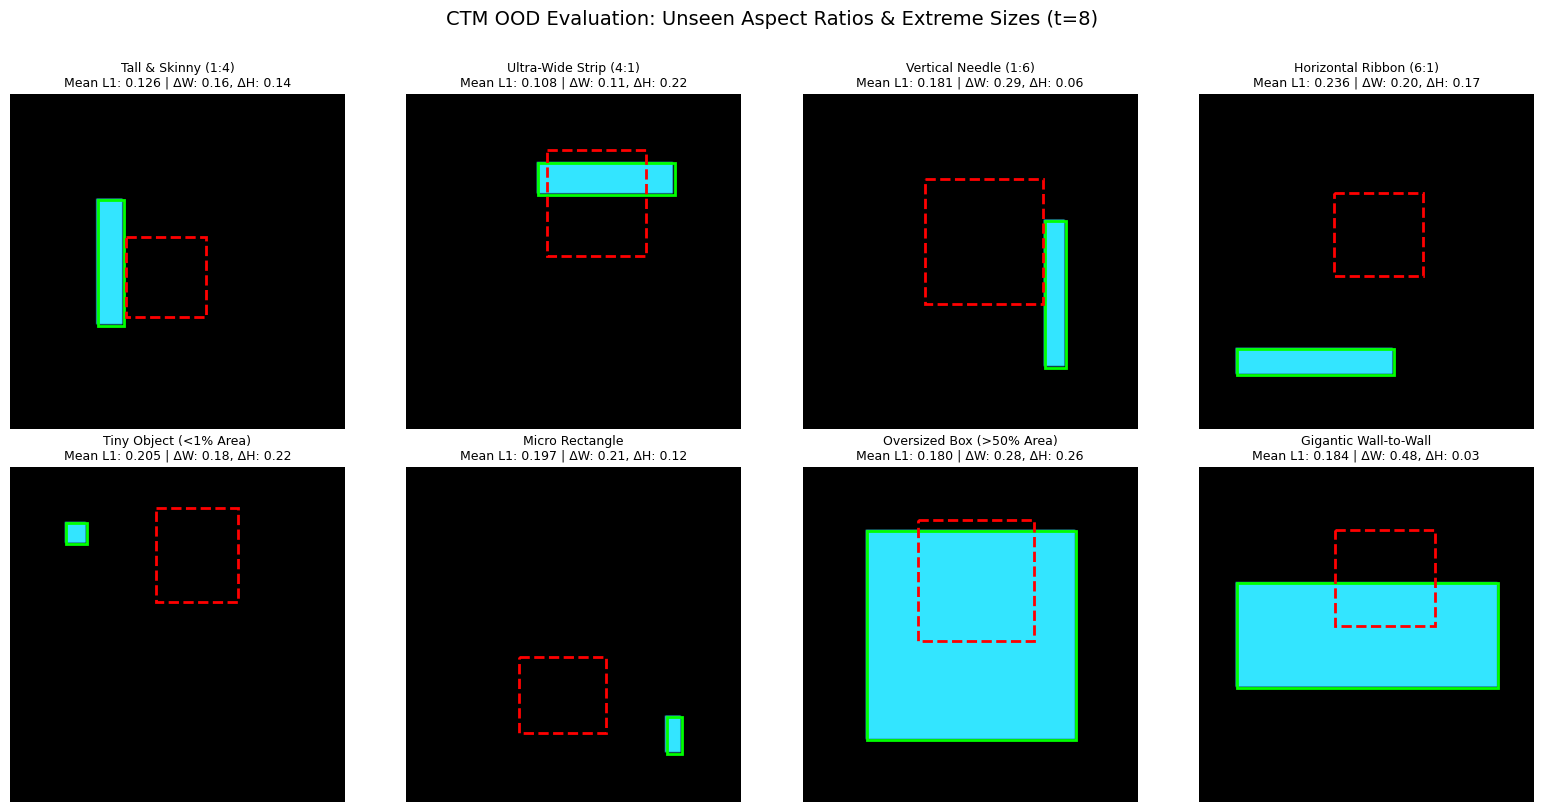

In [ ]:

# =====================================================================
# 1. Aspect Ratio & Scale OOD Dataset Generator
# =====================================================================
class SizeAndShapeOODGenerator:
    """Generates synthetic bounding boxes with extreme, non-standard shapes and sizes."""

    @staticmethod
    def generate_extreme_size_samples(img_size=128):
        """
        Generates images featuring rectangles with unseen aspect ratios and extreme scales.
        """
        images, boxes, category_labels = [], [], []
        torch.manual_seed(404)

        # Specifications: (Name, Center X Ratio, Center Y Ratio, Width Px, Height Px)
        configs = [
            # Extreme Aspect Ratios
            ("Tall & Skinny (1:4)", 0.30, 0.50, 10, 48),
            ("Ultra-Wide Strip (4:1)", 0.60, 0.25, 52, 12),
            ("Vertical Needle (1:6)", 0.75, 0.60, 8, 56),
            ("Horizontal Ribbon (6:1)", 0.35, 0.80, 60, 10),

            # Extreme Scales
            ("Tiny Object (<1% Area)", 0.20, 0.20, 8, 8),
            ("Micro Rectangle", 0.80, 0.80, 6, 14),
            ("Oversized Box (>50% Area)", 0.50, 0.50, 80, 80),
            ("Gigantic Wall-to-Wall", 0.50, 0.50, 100, 40),
        ]

        y_grid, x_grid = torch.meshgrid(
            torch.arange(img_size), torch.arange(img_size), indexing="ij"
        )

        for name, x_ratio, y_ratio, w_px, h_px in configs:
            img = torch.zeros(3, img_size, img_size, dtype=torch.float32)

            x_c_px = int(x_ratio * img_size)
            y_c_px = int(y_ratio * img_size)

            x1 = max(0, x_c_px - w_px // 2)
            x2 = min(img_size, x_c_px + w_px // 2)
            y1 = max(0, y_c_px - h_px // 2)
            y2 = min(img_size, y_c_px + h_px // 2)

            # Bright Cyan / White fill to highlight structural boundaries
            img[0, y1:y2, x1:x2] = 0.2
            img[1, y1:y2, x1:x2] = 0.9
            img[2, y1:y2, x1:x2] = 1.0

            # Ground truth bounding box [cx, cy, w, h] normalized
            actual_w = (x2 - x1) / img_size
            actual_h = (y2 - y1) / img_size
            actual_cx = ((x1 + x2) / 2.0) / img_size
            actual_cy = ((y1 + y2) / 2.0) / img_size

            box = torch.tensor([actual_cx, actual_cy, actual_w, actual_h], dtype=torch.float32)

            images.append(img)
            boxes.append(box)
            category_labels.append(name)

        return torch.stack(images), torch.stack(boxes), category_labels


# =====================================================================
# 2. Size & Aspect Ratio OOD Visualization
# =====================================================================
def visualize_size_ood_results(model, images, boxes, category_labels, step_horizon=8):
    """
    Plots ground truth vs predicted bounding boxes across 8 non-standard size/shape cases.
    """
    model.eval()
    images = images.to(device)
    boxes = boxes.to(device)
    num_samples = len(images)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    print(f"\n--- Evaluating Size & Aspect Ratio OOD Performance at Thought Step t={step_horizon} ---")

    with torch.no_grad():
        original_max_steps = model.max_steps
        model.max_steps = step_horizon

        for idx in range(num_samples):
            img_tensor = images[idx]
            gt_box = boxes[idx].cpu().numpy()

            x = img_tensor.unsqueeze(0).to(device)
            traj_boxes = model(x)  # (steps, 1, num_queries, 4)
            final_boxes = traj_boxes[-1, 0].cpu()  # (num_queries, 4)

            # Select query box with minimum L1 error to ground truth
            target_exp = torch.tensor(gt_box).unsqueeze(0).repeat(model.num_queries, 1)
            l1_dists = torch.abs(final_boxes - target_exp).sum(dim=-1)
            best_pred_box = final_boxes[l1_dists.argmin()].numpy()

            # Prepare image display
            img_np = img_tensor.cpu().permute(1, 2, 0).numpy()
            img_h, img_w, _ = img_np.shape
            gt_cx, gt_cy, gt_w, gt_h = gt_box

            ax = axes[idx]
            ax.imshow(img_np)

            # 1. Ground Truth Box (Lime Green)
            gt_rect = patches.Rectangle(
                ((gt_cx - gt_w / 2) * img_w, (gt_cy - gt_h / 2) * img_h),
                gt_w * img_w, gt_h * img_h,
                linewidth=2, edgecolor='lime', facecolor='none', label='GT'
            )
            ax.add_patch(gt_rect)

            # 2. CTM Prediction Box (Dashed Red)
            p_cx, p_cy, p_w, p_h = best_pred_box
            pred_rect = patches.Rectangle(
                ((p_cx - p_w / 2) * img_w, (p_cy - p_h / 2) * img_h),
                p_w * img_w, p_h * img_h,
                linewidth=2, edgecolor='red', linestyle='--', facecolor='none', label='Pred'
            )
            ax.add_patch(pred_rect)

            # Compute error metrics
            l1_err = np.abs(best_pred_box - gt_box).mean()
            w_err = np.abs(p_w - gt_w)
            h_err = np.abs(p_h - gt_h)

            label_text = category_labels[idx]
            ax.set_title(
                f"{label_text}\nMean L1: {l1_err:.3f} | ΔW: {w_err:.2f}, ΔH: {h_err:.2f}",
                fontsize=9
            )
            ax.axis('off')

        model.max_steps = original_max_steps

    plt.suptitle(
        f"CTM OOD Evaluation: Unseen Aspect Ratios & Extreme Sizes (t={step_horizon})",
        fontsize=14, y=1.01
    )
    plt.tight_layout()
    plt.show()


# =====================================================================
# Execution Block
# =====================================================================
if __name__ == "__main__":
    # 1. Generate OOD size and aspect ratio dataset
    ood_imgs, ood_boxes, ood_labels = SizeAndShapeOODGenerator.generate_extreme_size_samples(img_size=128)

    # 2. Run model and plot predictions at thought horizon t=8
    visualize_size_ood_results(
        trained_model,
        ood_imgs,
        ood_boxes,
        ood_labels,
        step_horizon=8
    )

Starting training on 4000 samples for 12 epochs...
Epoch [01/12] | Train Loss: 1.0672 | Val Loss: 0.9554 | LR: 0.000295
Epoch [02/12] | Train Loss: 0.9489 | Val Loss: 0.9028 | LR: 0.000280
Epoch [03/12] | Train Loss: 0.8721 | Val Loss: 0.8311 | LR: 0.000256
Epoch [04/12] | Train Loss: 0.8344 | Val Loss: 0.8152 | LR: 0.000225
Epoch [05/12] | Train Loss: 0.8078 | Val Loss: 0.8032 | LR: 0.000189
Epoch [06/12] | Train Loss: 0.8078 | Val Loss: 0.7511 | LR: 0.000150
Epoch [07/12] | Train Loss: 0.7739 | Val Loss: 0.7699 | LR: 0.000111
Epoch [08/12] | Train Loss: 0.7601 | Val Loss: 0.7760 | LR: 0.000075
Epoch [09/12] | Train Loss: 0.7683 | Val Loss: 0.7179 | LR: 0.000044
Epoch [10/12] | Train Loss: 0.7460 | Val Loss: 0.7350 | LR: 0.000020
Epoch [11/12] | Train Loss: 0.7525 | Val Loss: 0.7103 | LR: 0.000005
Epoch [12/12] | Train Loss: 0.7470 | Val Loss: 0.7121 | LR: 0.000000
Training complete.


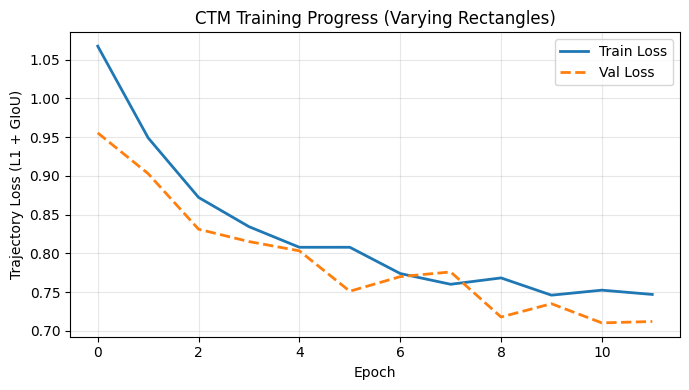

In [ ]:

# =====================================================================
# 1. Dataset: Rectangles with Varying Size and Aspect Ratio
# =====================================================================
class VaryingRectangleDataset(Dataset):
    """
    Generates synthetic images containing rectangles with randomly sampled:
    - Center positions (x, y)
    - Scales (width, height from 8px to 90px)
    - Aspect ratios (ranging from tall/skinny to short/wide)
    - RGB colors and subtle background variations
    """
    def __init__(self, num_samples=5000, img_size=128, min_size=8, max_size=90):
        super().__init__()
        self.num_samples = num_samples
        self.img_size = img_size
        self.min_size = min_size
        self.max_size = max_size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Image buffer with light ambient noise
        img = torch.randn(3, self.img_size, self.img_size) * 0.02

        # 1. Sample width and height independently to vary aspect ratio
        w_px = torch.randint(self.min_size, self.max_size + 1, (1,)).item()
        h_px = torch.randint(self.min_size, self.max_size + 1, (1,)).item()

        # 2. Sample center ensuring rectangle stays within image boundaries
        half_w = w_px // 2
        half_h = h_px // 2
        x_c_px = torch.randint(half_w + 2, self.img_size - half_w - 2, (1,)).item()
        y_c_px = torch.randint(half_h + 2, self.img_size - half_h - 2, (1,)).item()

        # Bounding pixel boundaries
        x1, x2 = x_c_px - half_w, x_c_px + half_w
        y1, y2 = y_c_px - half_h, y_c_px + half_h

        # 3. Random RGB color for target rectangle
        color = torch.rand(3, 1, 1) * 0.7 + 0.3  # Brightness range [0.3, 1.0]
        img[:, y1:y2, x1:x2] = color

        img = torch.clamp(img, 0.0, 1.0)

        # Normalized coordinates [cx, cy, w, h] in range [0, 1]
        box = torch.tensor([
            x_c_px / self.img_size,
            y_c_px / self.img_size,
            w_px / self.img_size,
            h_px / self.img_size
        ], dtype=torch.float32)

        return img, box


# =====================================================================
# 2. Bounding Box Metric Utilities (GIoU & Loss)
# =====================================================================
def box_cxcywh_to_xyxy(x):
    """Converts bounding boxes from (cx, cy, w, h) to (x1, y1, x2, y2)."""
    cx, cy, w, h = x.unbind(-1)
    b = [(cx - 0.5 * w), (cy - 0.5 * h), (cx + 0.5 * w), (cy + 0.5 * h)]
    return torch.stack(b, dim=-1)

def generalized_box_iou(boxes1, boxes2):
    """
    Computes GIoU loss between predicted and ground truth bounding boxes.
    `boxes1` and `boxes2` are expected in (cx, cy, w, h) format.
    """
    b1_xy = box_cxcywh_to_xyxy(boxes1)
    b2_xy = box_cxcywh_to_xyxy(boxes2)

    # Intersection
    lt = torch.max(b1_xy[..., :2], b2_xy[..., :2])
    rb = torch.min(b1_xy[..., 2:], b2_xy[..., 2:])
    wh = (rb - lt).clamp(min=0)
    intersection = wh[..., 0] * wh[..., 1]

    # Areas
    area1 = (b1_xy[..., 2] - b1_xy[..., 0]) * (b1_xy[..., 3] - b1_xy[..., 1])
    area2 = (b2_xy[..., 2] - b2_xy[..., 0]) * (b2_xy[..., 3] - b2_xy[..., 1])
    union = area1 + area2 - intersection

    iou = intersection / (union + 1e-6)

    # Enclosing area
    enclose_lt = torch.min(b1_xy[..., :2], b2_xy[..., :2])
    enclose_rb = torch.max(b1_xy[..., 2:], b2_xy[..., 2:])
    enclose_wh = (enclose_rb - enclose_lt).clamp(min=0)
    enclose_area = enclose_wh[..., 0] * enclose_wh[..., 1]

    giou = iou - (enclose_area - union) / (enclose_area + 1e-6)
    return 1.0 - giou  # GIoU Loss


def compute_ctm_detection_loss(traj_boxes, target_boxes, l1_weight=5.0, giou_weight=2.0):
    """
    Computes trajectory loss across all CTM thought steps.
    Applies minimum-distance matching between queries and ground truth per step.

    Args:
        traj_boxes: Tensor of shape (steps, B, num_queries, 4)
        target_boxes: Tensor of shape (B, 4)
    """
    steps, batch_size, num_queries, _ = traj_boxes.shape
    total_loss = 0.0

    target_exp = target_boxes.unsqueeze(1).repeat(1, num_queries, 1)  # (B, num_queries, 4)

    for t in range(steps):
        pred_t = traj_boxes[t]  # (B, num_queries, 4)

        # L1 distances per query
        l1_dists = torch.abs(pred_t - target_exp).sum(dim=-1)  # (B, num_queries)
        best_indices = l1_dists.argmin(dim=1)                 # (B,)

        matched_preds = pred_t[torch.arange(batch_size), best_indices]  # (B, 4)

        # Loss components
        l1_loss = torch.abs(matched_preds - target_boxes).mean()
        giou_l = generalized_box_iou(matched_preds, target_boxes).mean()

        step_loss = l1_weight * l1_loss + giou_weight * giou_l

        # Discount factor: give higher weight to later thought steps
        step_weight = (t + 1) / steps
        total_loss += step_weight * step_loss

    return total_loss / steps


# =====================================================================
# 3. Training Loop
# =====================================================================
def train_ctm_on_varying_rectangles(
    model,
    num_epochs=15,
    batch_size=32,
    learning_rate=3e-4,
    img_size=128
):
    """Complete training pipeline for varying size and aspect ratio rectangles."""

    # Dataloaders
    train_dataset = VaryingRectangleDataset(num_samples=4000, img_size=img_size)
    val_dataset = VaryingRectangleDataset(num_samples=500, img_size=img_size)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    model.to(device)
    print(f"Starting training on {len(train_dataset)} samples for {num_epochs} epochs...")

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, num_epochs + 1):
        # --- Training ---
        model.train()
        running_train_loss = 0.0

        for images, boxes in train_loader:
            images, boxes = images.to(device), boxes.to(device)

            optimizer.zero_grad()
            traj_boxes = model(images)  # Output shape: (steps, B, num_queries, 4)
            loss = compute_ctm_detection_loss(traj_boxes, boxes)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_train_loss += loss.item()

        epoch_train_loss = running_train_loss / len(train_loader)
        history["train_loss"].append(epoch_train_loss)

        # --- Validation ---
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for images, boxes in val_loader:
                images, boxes = images.to(device), boxes.to(device)
                traj_boxes = model(images)
                loss = compute_ctm_detection_loss(traj_boxes, boxes)
                running_val_loss += loss.item()

        epoch_val_loss = running_val_loss / len(val_loader)
        history["val_loss"].append(epoch_val_loss)

        scheduler.step()

        print(
            f"Epoch [{epoch:02d}/{num_epochs:02d}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"LR: {scheduler.get_last_lr()[0]:.6f}"
        )

    print("Training complete.")
    return model, history


# =====================================================================
# 4. Execution Block
# =====================================================================
if __name__ == "__main__":
    # Assumes `trained_model` or `CTMObjectDetector` is initialized
    # e.g., model = CTMObjectDetector(...).to(device)

    trained_model, training_history = train_ctm_on_varying_rectangles(
        model=trained_model,
        num_epochs=12,
        batch_size=32,
        learning_rate=3e-4,
        img_size=128
    )

    # Plot Training Loss Curve
    plt.figure(figsize=(7, 4))
    plt.plot(training_history["train_loss"], label="Train Loss", linewidth=2)
    plt.plot(training_history["val_loss"], label="Val Loss", linestyle="--", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Trajectory Loss (L1 + GIoU)")
    plt.title("CTM Training Progress (Varying Rectangles)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


   Evaluating Model on Extreme OOD Sizes & Aspect Ratios        
Thought Steps t=02 | Mean L1: 0.0717 | Width Err (ΔW): 0.1360 | Height Err (ΔH): 0.0878
Thought Steps t=06 | Mean L1: 0.0624 | Width Err (ΔW): 0.1195 | Height Err (ΔH): 0.0874
Thought Steps t=12 | Mean L1: 0.0691 | Width Err (ΔW): 0.1096 | Height Err (ΔH): 0.1049


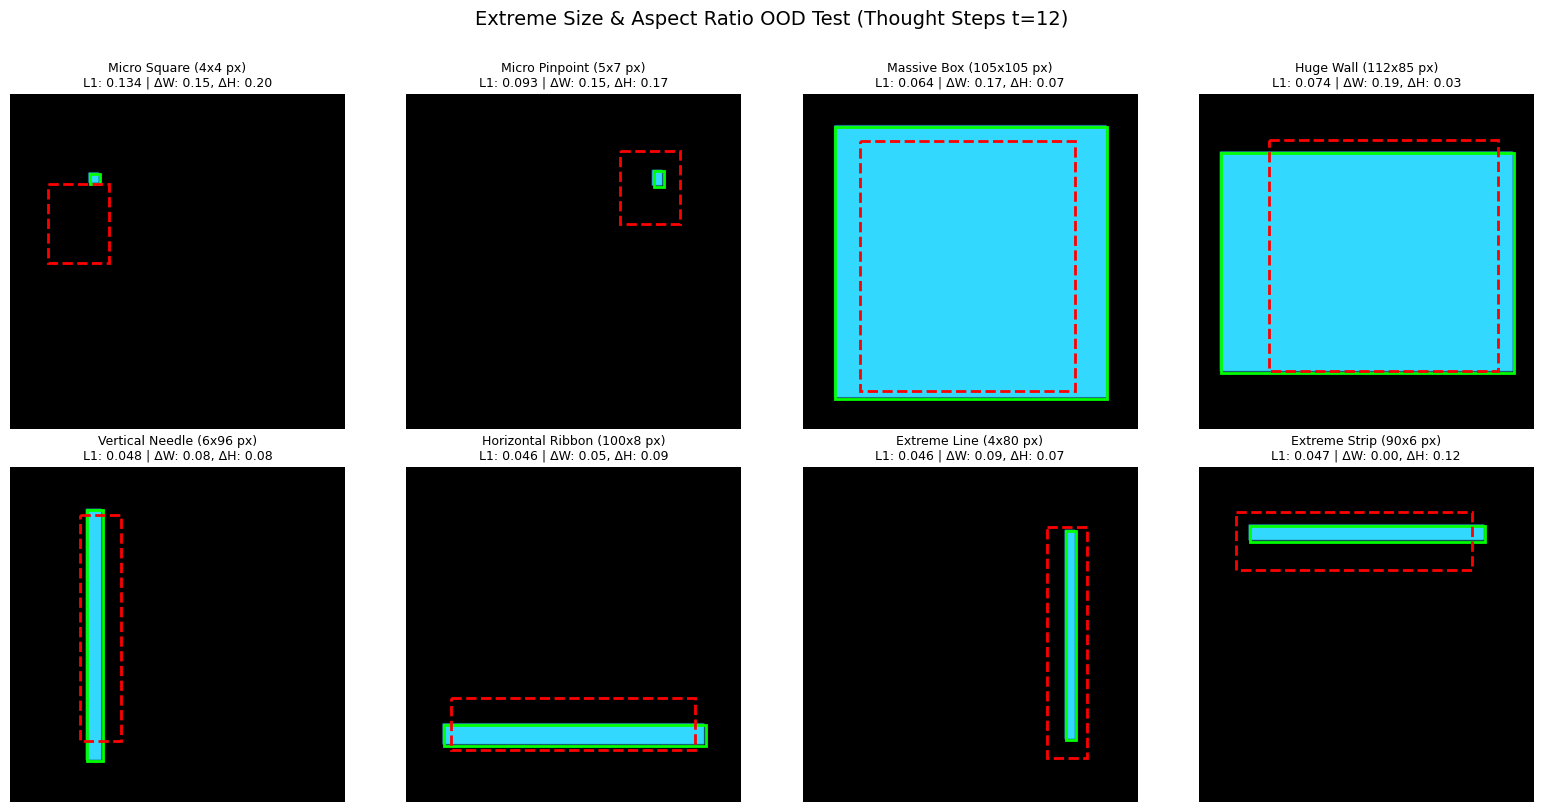

In [ ]:


# =====================================================================
# 1. Extreme Size & Aspect Ratio OOD Data Generator
# =====================================================================
class ExtremeOODSizeGenerator:
    """
    Generates synthetic targets strictly OUTSIDE the training/validation bounds:
    - Sizes < 8px or > 90px
    - Aspect ratios more extreme than 1:11 or 11:1
    """
    @staticmethod
    def generate_extreme_ood_samples(img_size=128):
        images, boxes, category_labels = [], [], []
        torch.manual_seed(707)

        # Configs: (Category Name, x_center_ratio, y_center_ratio, w_px, h_px)
        # Note: Training was restricted to [8, 90] px
        configs = [
            # 1. Ultra-Small OOD (< 8px)
            ("Micro Square (4x4 px)", 0.25, 0.25, 4, 4),
            ("Micro Pinpoint (5x7 px)", 0.75, 0.25, 5, 7),

            # 2. Oversized OOD (> 90px)
            ("Massive Box (105x105 px)", 0.50, 0.50, 105, 105),
            ("Huge Wall (112x85 px)", 0.50, 0.50, 112, 85),

            # 3. Extreme Aspect Ratio OOD (> 1:12 or > 12:1)
            ("Vertical Needle (6x96 px)", 0.25, 0.50, 6, 96),
            ("Horizontal Ribbon (100x8 px)", 0.50, 0.80, 100, 8),
            ("Extreme Line (4x80 px)", 0.80, 0.50, 4, 80),
            ("Extreme Strip (90x6 px)", 0.50, 0.20, 90, 6),
        ]

        for name, x_ratio, y_ratio, w_px, h_px in configs:
            img = torch.zeros(3, img_size, img_size, dtype=torch.float32)

            x_c_px = int(x_ratio * img_size)
            y_c_px = int(y_ratio * img_size)

            x1 = max(0, x_c_px - w_px // 2)
            x2 = min(img_size, x_c_px + w_px // 2)
            y1 = max(0, y_c_px - h_px // 2)
            y2 = min(img_size, y_c_px + h_px // 2)

            # Bright target highlight
            img[0, y1:y2, x1:x2] = 0.2
            img[1, y1:y2, x1:x2] = 0.85
            img[2, y1:y2, x1:x2] = 1.0

            # Ground truth bounding box [cx, cy, w, h] normalized
            actual_w = (x2 - x1) / img_size
            actual_h = (y2 - y1) / img_size
            actual_cx = ((x1 + x2) / 2.0) / img_size
            actual_cy = ((y1 + y2) / 2.0) / img_size

            box = torch.tensor([actual_cx, actual_cy, actual_w, actual_h], dtype=torch.float32)

            images.append(img)
            boxes.append(box)
            category_labels.append(name)

        return torch.stack(images), torch.stack(boxes), category_labels


# =====================================================================
# 2. OOD Performance Evaluation & Visualization Function
# =====================================================================
def evaluate_and_visualize_extreme_ood(
    model,
    ood_images,
    ood_boxes,
    category_labels,
    step_horizons=[2, 6, 12]
):
    """
    Evaluates CTM model on extreme OOD size/shape samples across varying
    thought-step limits (t) to test if increased ponder time improves OOD fit.
    """
    model.eval()
    ood_images = ood_images.to(device)
    ood_boxes = ood_boxes.to(device)
    num_samples = len(ood_images)

    print("\n=================================================================")
    print("   Evaluating Model on Extreme OOD Sizes & Aspect Ratios        ")
    print("=================================================================")

    # Quantitative Evaluation across Thought Steps
    for t in step_horizons:
        original_max_steps = model.max_steps
        model.max_steps = t

        with torch.no_grad():
            traj_boxes = model(ood_images)       # (steps, B, num_queries, 4)
            final_boxes = traj_boxes[-1]         # (B, num_queries, 4)

            # Match best query per sample
            target_exp = ood_boxes.unsqueeze(1).repeat(1, model.num_queries, 1)
            l1_dists = torch.abs(final_boxes - target_exp).sum(dim=-1)
            best_indices = l1_dists.argmin(dim=1)

            matched_preds = final_boxes[torch.arange(num_samples), best_indices]

            mean_l1 = torch.abs(matched_preds - ood_boxes).mean().item()
            w_err = torch.abs(matched_preds[:, 2] - ood_boxes[:, 2]).mean().item()
            h_err = torch.abs(matched_preds[:, 3] - ood_boxes[:, 3]).mean().item()

            print(f"Thought Steps t={t:02d} | Mean L1: {mean_l1:.4f} | Width Err (ΔW): {w_err:.4f} | Height Err (ΔH): {h_err:.4f}")

        model.max_steps = original_max_steps

    # Visual Grid Plotting at max thought horizon
    eval_step = step_horizons[-1]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    with torch.no_grad():
        model.max_steps = eval_step
        traj_boxes = model(ood_images)
        final_boxes = traj_boxes[-1]

        for idx in range(num_samples):
            img_tensor = ood_images[idx]
            gt_box = ood_boxes[idx].cpu().numpy()

            # Best matching query selection
            target_exp = torch.tensor(gt_box).unsqueeze(0).repeat(model.num_queries, 1).to(device)
            l1_dists = torch.abs(final_boxes[idx] - target_exp).sum(dim=-1)
            best_pred_box = final_boxes[idx, l1_dists.argmin()].cpu().numpy()

            img_np = img_tensor.cpu().permute(1, 2, 0).numpy()
            img_h, img_w, _ = img_np.shape
            gt_cx, gt_cy, gt_w, gt_h = gt_box

            ax = axes[idx]
            ax.imshow(img_np)

            # Ground Truth Box (Green)
            gt_rect = patches.Rectangle(
                ((gt_cx - gt_w / 2) * img_w, (gt_cy - gt_h / 2) * img_h),
                gt_w * img_w, gt_h * img_h,
                linewidth=2, edgecolor='lime', facecolor='none', label='GT'
            )
            ax.add_patch(gt_rect)

            # CTM Prediction Box (Red)
            p_cx, p_cy, p_w, p_h = best_pred_box
            pred_rect = patches.Rectangle(
                ((p_cx - p_w / 2) * img_w, (p_cy - p_h / 2) * img_h),
                p_w * img_w, p_h * img_h,
                linewidth=2, edgecolor='red', linestyle='--', facecolor='none', label='Pred'
            )
            ax.add_patch(pred_rect)

            l1_err = np.abs(best_pred_box - gt_box).mean()
            dw = np.abs(p_w - gt_w)
            dh = np.abs(p_h - gt_h)

            ax.set_title(
                f"{category_labels[idx]}\nL1: {l1_err:.3f} | ΔW: {dw:.2f}, ΔH: {dh:.2f}",
                fontsize=9
            )
            ax.axis('off')

    plt.suptitle(
        f"Extreme Size & Aspect Ratio OOD Test (Thought Steps t={eval_step})",
        fontsize=14, y=1.01
    )
    plt.tight_layout()
    plt.show()


# =====================================================================
# Execution Block
# =====================================================================
if __name__ == "__main__":
    # 1. Generate Extreme OOD dataset (outside [8, 90] px range)
    ood_imgs, ood_boxes, ood_labels = ExtremeOODSizeGenerator.generate_extreme_ood_samples(img_size=128)

    # 2. Run evaluation and plot predictions across t = [2, 6, 12]
    evaluate_and_visualize_extreme_ood(
        trained_model,
        ood_imgs,
        ood_boxes,
        ood_labels,
        step_horizons=[2, 6, 12]
    )